In [1]:
import glob
import json
import random
import re
from os.path import join as opj

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

from cloth_fmri.config.config import CONFIG
from cloth_fmri.utils.stats import bootstrap_cor
from cloth_fmri.utils.svm import (
    get_videomae_distance,
    get_vivit_distance,
    get_vjepa2_distance,
)

random.seed(9)
SCENES = CONFIG["scenes"]
BOOTN = 10000

VIDEO_MODEL_DIRS = {
    "V-JEPA2": "vjepa2_hf_ridge_mean_1.0_ntrain=7075",
    "VideoMAE": "videomae_ridge_mean_1.0_ntrain=7075",
    "ViViT": "vivit_ridge_cls_1.0_ntrain=7075",
}
DISTANCE_FUNCTIONS = {
    "V-JEPA2": get_vjepa2_distance,
    "VideoMAE": get_videomae_distance,
    "ViViT": get_vivit_distance,
}


def get_available_layers(model):
    pred_dir = opj(
        CONFIG["output_root"],
        "analysis",
        "model_predictions_all_layers",
        VIDEO_MODEL_DIRS[model],
    )

    files = glob.glob(
        opj(pred_dir, "pred_dict_layer_index=*_layer_number=*.npy")
    )

    layers = []
    for path in files:
        match = re.search(r"layer_index=(\d+)", path)
        if match is not None:
            layers.append(int(match.group(1)))

    layers = sorted(set(layers))

    if not layers:
        raise FileNotFoundError(
            f"No layer prediction files found for {model}: {pred_dir}"
        )

    return layers


/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/nilearn/__init__.py:67: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()


In [2]:
# Select Physics ROI decoding results using the original split-half criterion.
best_split_half_r = -1
physics_acc = None
best_params = None
for leave_scene in ["1", "2"]:
    for c in ["0.1", "1.0", "10.0", "100.0"]:
        for smooth in ["0", "1", "2"]:
            input_dir = opj(
                CONFIG["output_root"], "analysis", "fig3",
                f"leave-{leave_scene}-run-out", f"C={c}", f"smooth={smooth}", "tower",
            )
            files = glob.glob(opj(input_dir, "*.json"))
            if not files:
                continue

            all_data = []
            expected_subjects = None
            for path in files:
                with open(path, "r") as f:
                    data = json.load(f)["tower_acc_all_tmps"]
                subjects = sorted(data)
                if expected_subjects is None:
                    expected_subjects = subjects
                elif subjects != expected_subjects:
                    raise ValueError(f"Subject IDs differ across files in {input_dir}")
                all_data.append(np.array([
                    [np.mean(data[sub][scene]) for scene in SCENES]
                    for sub in subjects
                ]))

            acc = np.mean(np.array(all_data), axis=0)
            split_half_r, split_half_p, _ = bootstrap_cor(acc, seed=99)
            if split_half_r > best_split_half_r:
                best_split_half_r = split_half_r
                best_split_half_p = split_half_p
                physics_acc = acc
                best_params = {"leave_scene": leave_scene, "C": c, "smooth": smooth}

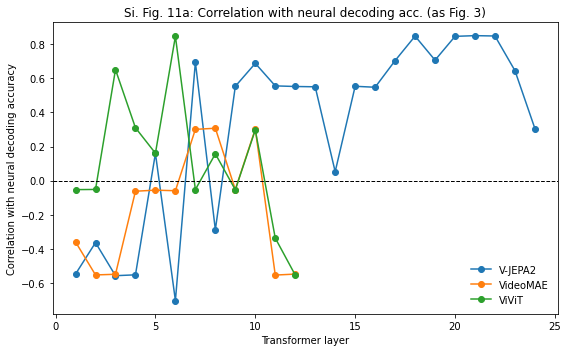

In [3]:
# Keep the original plotted statistic: mean Spearman correlation over
# participant bootstrap samples, using each model's first 62 distances per scene.
nsub = physics_acc.shape[0]
fig, ax = plt.subplots(figsize=(8, 5))
all_layer_results = []

for model, get_distance in DISTANCE_FUNCTIONS.items():
    layers = get_available_layers(model)
    layer_correlations = []
    for layer in layers:
        distances = get_distance(verbose=False, layer=layer)
        model_mean = [np.mean(distances[scene][:62]) for scene in SCENES]
        bootstrap_rs = []
        for _ in range(BOOTN):
            indices = np.random.choice(nsub, nsub, replace=True)
            human_mean = np.mean(physics_acc[indices, :], axis=0)
            bootstrap_rs.append(spearmanr(model_mean, human_mean)[0])

        mean_r = np.nanmean(bootstrap_rs)
        layer_correlations.append(mean_r)
        all_layer_results.append({
            "model": model,
            "layer_index": layer,
            "layer_number": layer + 1,
            "physics_bootstrap_mean_spearman": mean_r,
        })

    ax.plot(np.array(layers) + 1, layer_correlations, marker="o", label=model)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Transformer layer")
ax.set_ylabel("Correlation with neural decoding accuracy")
ax.set_title("Si. Fig. 11a: Correlation with neural decoding acc. (as Fig. 3)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()